# Comprehensive Klinkenberg Effect & Gas Permeability Analysis
**Advanced Petrophysics & Reservoir Engineering Technical Report**

---

## 1. Executive Summary & Physics Background
In rock mechanics and reservoir engineering, fluid flow through porous media is conventionally governed by **Darcy's Law**. However, when measuring permeability using gases (e.g., nitrogen, helium, air) rather than incompressible liquids (e.g., brine, crude oil), the apparent permeability ($k_g$) varies inversely with mean operating pressure ($P_m$).

This phenomenon, known as the **Klinkenberg Effect** (or **Gas Slippage Effect**), occurs because gas molecules undergo kinetic slip along pore walls when the mean free path of gas molecules approaches the pore throat diameter. As mean pressure approaches infinity ($1/P_m \to 0$), gas density increases, molecular collisions with each other dominate over pore wall collisions, and gas flow transitions to continuum liquid behavior ($k_g \to k_l$).

## 2. Fluid Dynamics Regimes & Knudsen Number
To characterize fluid transport in porous media, we define the dimensionless **Knudsen Number** ($Kn$):

$$Kn = \frac{\lambda}{r_{pore}}$$

where:
- $\lambda$ = Mean free path of the gas molecules ($m$)
- $r_{pore}$ = Mean pore throat radius ($m$)

Flow regimes are classified according to $Kn$:
1. **Continuum Viscous Flow ($Kn < 0.01$):** Liquid flow; zero-velocity boundary condition at wall (Darcy's Law strictly holds).
2. **Slip Flow ($0.01 < Kn < 0.1$):** Gas slippage regime; Klinkenberg correction applies.
3. **Transition Flow ($0.1 < Kn < 10$):** High slippage / Knudsen diffusion dominant.
4. **Free Molecular Flow ($Kn > 10$):** Wall collisions dominate completely.

## 3. Mathematical Derivation: Darcy's Law for Compressible Gas Flow
Differential form of Darcy's Law for linear, horizontal flow:

$$q = -\frac{k_g A}{\mu} \frac{dp}{dx}$$

For an ideal gas undergoing isothermal flow, volumetric flow rate $q$ at local pressure $p$ relates to flow rate $q_{std}$ at reference pressure $P_{std}$ by $p q = P_{std} q_{std}$. Substituting gives:

$$\frac{P_{std} q_{std}}{p} = -\frac{k_g A}{\mu} \frac{dp}{dx}$$

Separating variables and integrating across core length $L$ (from inlet $P_{in}$ to outlet $P_{out}$):

$$P_{std} q_{std} \int_0^L dx = -\frac{k_g A}{\mu} \int_{P_{in}}^{P_{out}} p \, dp$$

$$P_{std} q_{std} L = \frac{k_g A}{2\mu} \left(P_{in}^2 - P_{out}^2\right)$$

Defining Mean Pressure $P_m = \frac{P_{in} + P_{out}}{2}$ and pressure drop $\Delta P = P_{in} - P_{out}$, we observe $P_{in}^2 - P_{out}^2 = 2 P_m \Delta P$. Thus:

$$q_m = \frac{k_g A}{\mu} \frac{\Delta P}{L}$$

where $q_m$ is the flow rate evaluated at mean pressure $P_m$.

## 4. Mathematical Derivation of the Klinkenberg Equation
L.J. Klinkenberg (1941) postulated that gas velocity at the pore boundary is non-zero, proportional to the mean free path $\lambda$:

$$v_{wall} = -c \lambda \left( \frac{dv}{dr} \right)_{wall}$$

Since kinetic gas theory states $\lambda \propto \frac{1}{P_m}$, gas permeability $k_g$ scales linearly with $\frac{1}{P_m}$:

$$k_g = k_l \left( 1 + \frac{b}{P_m} \right)$$

where:
- $k_g$ = Apparent gas permeability (mD)
- $k_l$ = True equivalent liquid permeability (mD)
- $b$ = Klinkenberg gas slippage factor (psi or atm)
- $P_m$ = Mean pore pressure = $\frac{P_{in} + P_{out}}{2}$

## 5. Gas Permeability vs. Liquid Permeability

| Feature / Parameter | Gas Permeability ($k_g$) | Liquid Permeability ($k_l$) |
| :--- | :--- | :--- |
| **Boundary Condition** | Non-zero slip velocity at pore wall | Zero slip velocity (adhesion force) |
| **Pressure Dependency** | High (inversely proportional to $P_m$) | Independent of pore pressure |
| **Pore Size Sensitivity** | Extreme in micro/nanopores (tight gas) | Minimal slip effects |
| **Testing Media** | Nitrogen, Helium, Air, $\text{CO}_2$ | Brine, Deaerated Water, Mineral Oil |
| **Magnitude Relationship** | Always $k_g > k_l$ at finite pressures | $k_l = \lim_{P_m \to \infty} k_g$ |

## 6. Scientific Computing Setup & Styling Settings

In [1]:
# Import core scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress, t

# Set random seed for deterministic reproducibility
np.random.seed(42)

# Configure publication-quality plot aesthetics
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--'
})

## 7. Experimental Core Flood Dataset Generation
Simulating core flood measurements recorded under steady-state laboratory conditions. Inlet pressure ($P_{in}$) varies from 18 to 136 psi, while atmospheric outlet pressure ($P_{out}$) remains fixed at 14.7 psi.

In [2]:
# Define experimental pressure protocol and standard flow measurements
flow_rate = np.array([0.30, 0.45, 0.62, 0.82, 1.05, 1.35, 1.70, 2.05, 2.50, 3.10, 3.80, 4.70, 5.80, 7.00, 8.50, 10.20, 12.00]) # cm3/s
pin = np.array([18, 22, 27, 33, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136], dtype=float) # psig
pout = np.full_like(pin, 14.7) # atmospheric pressure in psia

# Compute mean pressure (Pm) and inverse mean pressure (1/Pm)
pm = (pin + pout) / 2.0 # psia
inv_pm = 1.0 / pm # 1/psia

# Benchmark physical rock parameters
kl_true = 18.0   # True liquid permeability in mD
b_true = 220.0   # True Klinkenberg slippage parameter in psi

# Calculate theoretical gas permeability and inject Gaussian noise (~2% standard deviation)
k_true = kl_true * (1.0 + b_true * inv_pm)
noise = np.random.normal(0, 0.02, size=len(inv_pm))
k_measured = k_true * (1.0 + noise)

# Package into structured Pandas DataFrame
df_exp = pd.DataFrame({
    'Flow Rate (cm3/s)': flow_rate,
    'Inlet Pressure Pin (psia)': pin,
    'Outlet Pressure Pout (psia)': pout,
    'Mean Pressure Pm (psia)': pm,
    'Inv Mean Pressure 1/Pm (1/psi)': inv_pm,
    'Theoretical kg (mD)': k_true,
    'Measured kg (mD)': k_measured
})

print("Experimental dataset generation completed successfully.")

Experimental dataset generation completed successfully.


## 8. Experimental Laboratory Data Table
Summary of flow test readings and computed parameters.

In [3]:
# Display formatted experimental table
styled_df = df_exp.style.format({
    'Flow Rate (cm3/s)': '{:.2f}',
    'Inlet Pressure Pin (psia)': '{:.1f}',
    'Outlet Pressure Pout (psia)': '{:.1f}',
    'Mean Pressure Pm (psia)': '{:.2f}',
    'Inv Mean Pressure 1/Pm (1/psi)': '{:.4f}',
    'Theoretical kg (mD)': '{:.2f}',
    'Measured kg (mD)': '{:.2f}'
}).set_caption("Laboratory Core Flood Measurement Log")

display(styled_df)

,Flow Rate (cm3/s),Inlet Pressure Pin (psia),Outlet Pressure Pout (psia),Mean Pressure Pm (psia),Inv Mean Pressure 1/Pm (1/psi),Theoretical kg (mD),Measured kg (mD)
0,0.30,18.0,14.7,16.35,0.0612,260.20,262.79
1,0.45,22.0,14.7,18.35,0.0545,233.80,233.16
2,0.62,27.0,14.7,20.85,0.0480,207.93,210.62
3,0.82,33.0,14.7,23.85,0.0419,184.04,189.64
4,1.05,40.0,14.7,27.35,0.0366,162.79,162.03
5,1.35,48.0,14.7,31.35,0.0319,144.32,143.64
6,1.70,56.0,14.7,35.35,0.0283,130.02,134.13
7,2.05,64.0,14.7,39.35,0.0254,118.64,120.46
8,2.50,72.0,14.7,43.35,0.0231,109.35,108.32
9,3.10,80.0,14.7,47.35,0.0211,101.63,102.74


## 9. Ordinary Least Squares (OLS) & Statistical Derivation
Linear regression model fit: $k_g = a + b_{slope} \cdot \left(\frac{1}{P_m}\right)$

By parameter identification with $k_g = k_l + (k_l \cdot b) \frac{1}{P_m}$:
- **True Liquid Permeability ($k_l$):** $k_l = \text{Intercept } (a)$
- **Klinkenberg Slippage Factor ($b$):** $b = \frac{\text{Slope } (m)}{\text{Intercept } (a)}$

Standard error of estimate ($s_{y|x}$) with $d.o.f. = n - 2$:
$$s_{y|x} = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n - 2}}$$

95% Confidence Interval for mean predicted response $\hat{y}(x_0)$:
$$\hat{y}(x_0) \pm t_{\alpha/2, n-2} \cdot s_{y|x} \sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{\sum (x_i - \bar{x})^2}}$$

In [4]:
# Execute Ordinary Least Squares linear regression
res = linregress(inv_pm, k_measured)
slope, intercept = res.slope, res.intercept
r_value, r2 = res.rvalue, res.rvalue**2
std_err = res.stderr

# Physical parameters derived from regression
kl_calc = intercept
b_calc = slope / intercept

# Calculate confidence interval bands
n = len(inv_pm)
dof = n - 2
t_val = stats.t.ppf(0.975, dof)

x_vec = np.linspace(0, inv_pm.max() * 1.05, 300)
y_vec = intercept + slope * x_vec

# Residual error calculation
y_pred_data = intercept + slope * inv_pm
residuals = k_measured - y_pred_data
sy_x = np.sqrt(np.sum(residuals**2) / dof)

# Confidence interval calculation across domain
x_bar = np.mean(inv_pm)
ss_x = np.sum((inv_pm - x_bar)**2)
ci_band = t_val * sy_x * np.sqrt(1.0/n + ((x_vec - x_bar)**2) / ss_x)

print(f"Regression Summary Results:")
print(f"  - Liquid Permeability (kl): {kl_calc:.3f} mD")
print(f"  - Slippage Factor (b): {b_calc:.2f} psi")
print(f"  - R-squared (R2): {r2:.5f}")

Regression Summary Results:
  - Liquid Permeability (kl): 15.951 mD
  - Slippage Factor (b): 253.48 psi
  - R-squared (R2): 0.99892


## 10. Klinkenberg Linear Regression Plot with 95% Confidence Intervals
The extrapolation to $1/P_m = 0$ provides the absolute equivalent liquid permeability ($k_l$).

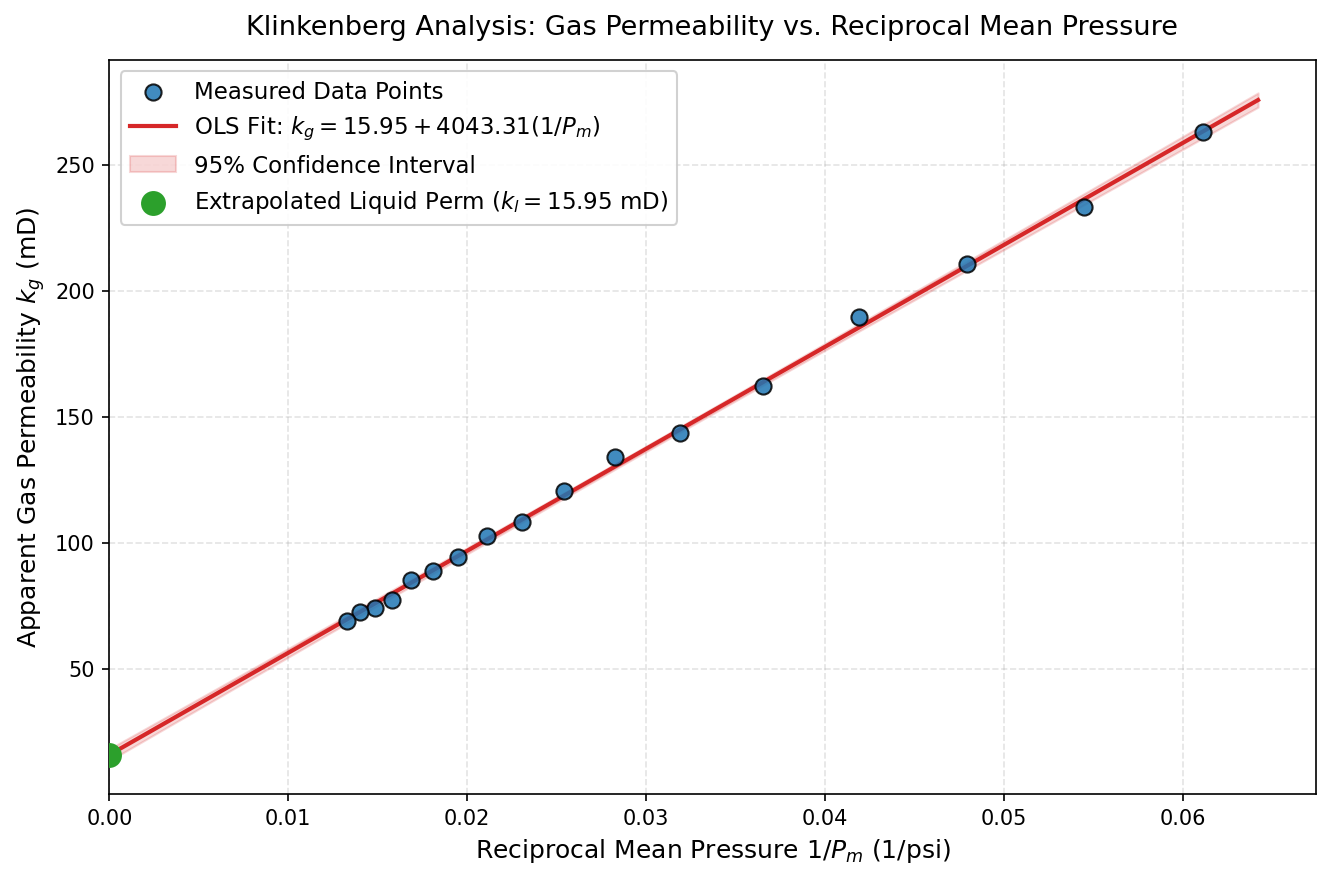

In [5]:
# Plot Figure 1: Klinkenberg Regression Plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot experimental scatter points
ax.scatter(inv_pm, k_measured, color='#1f77b4', edgecolor='k', s=60, alpha=0.85, label='Measured Data Points', zorder=4)

# Plot regression fit line
ax.plot(x_vec, y_vec, color='#d62728', lw=2, label=f'OLS Fit: $k_g = {intercept:.2f} + {slope:.2f}(1/P_m)$', zorder=3)

# Plot 95% confidence bands
ax.fill_between(x_vec, y_vec - ci_band, y_vec + ci_band, color='#d62728', alpha=0.18, label='95% Confidence Interval', zorder=2)

# Highlight kl intercept
ax.scatter([0], [kl_calc], color='#2ca02c', s=120, zorder=5, label=f'Extrapolated Liquid Perm ($k_l = {kl_calc:.2f}$ mD)')

# Plot formatting and labels
ax.set_title('Klinkenberg Analysis: Gas Permeability vs. Reciprocal Mean Pressure', pad=12)
ax.set_xlabel('Reciprocal Mean Pressure $1/P_m$ (1/psi)')
ax.set_ylabel('Apparent Gas Permeability $k_g$ (mD)')
ax.set_xlim(left=0)
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('Figure1_Klinkenberg_Plot.png', dpi=300)
plt.show()

## 11. Pressure Sensitivity & Gas Slippage Relative Error Analysis
Quantifying the magnitude of overestimation in gas permeability relative to true liquid permeability:

$$\text{Relative Error (\%)} = \frac{k_g - k_l}{k_l} \times 100\% = \frac{b}{P_m} \times 100\%$$

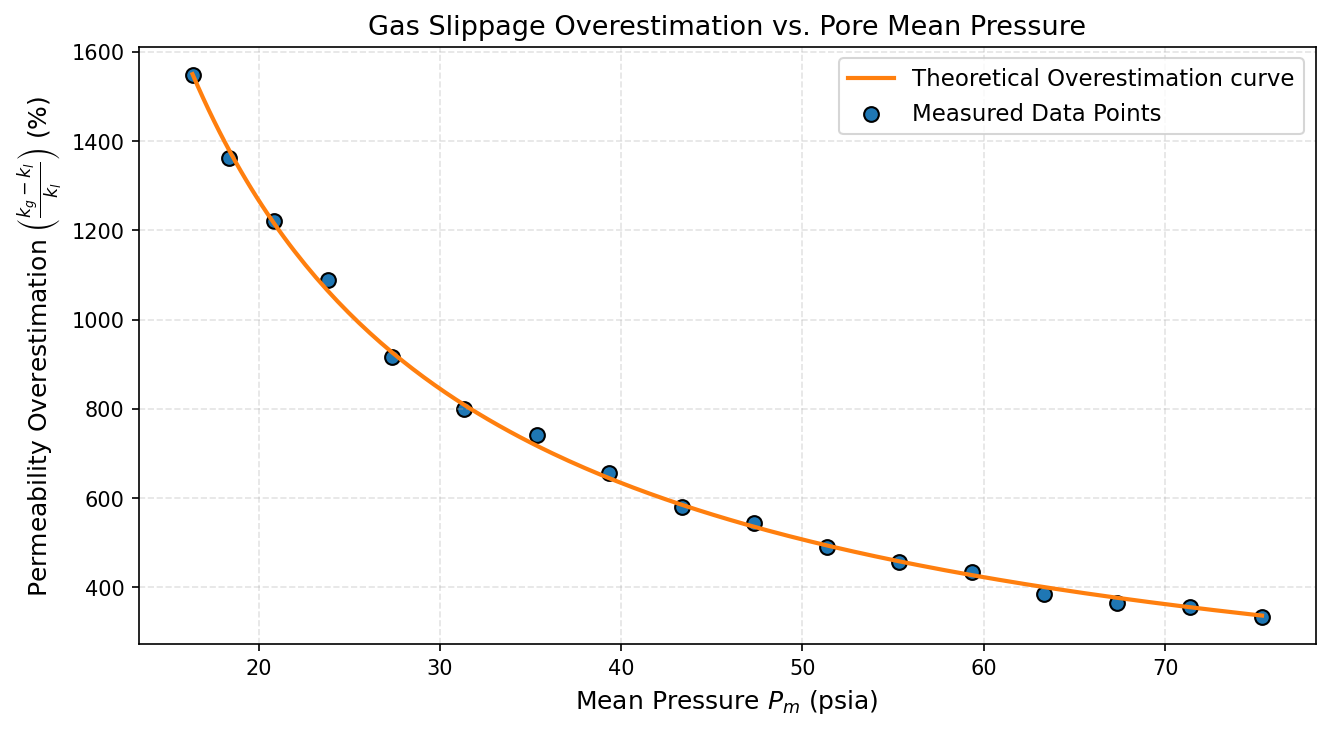

In [6]:
# Compute relative percentage deviation
rel_error_pct = ((k_measured - kl_calc) / kl_calc) * 100.0
pm_smooth = np.linspace(pm.min(), pm.max(), 200)
rel_error_theoretical = (b_calc / pm_smooth) * 100.0

# Plot Figure 2: Relative Error vs Mean Pressure
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(pm_smooth, rel_error_theoretical, color='#ff7f0e', lw=2, label='Theoretical Overestimation curve')
ax.scatter(pm, rel_error_pct, color='#1f77b4', edgecolor='k', s=50, label='Measured Data Points')

ax.set_title('Gas Slippage Overestimation vs. Pore Mean Pressure')
ax.set_xlabel('Mean Pressure $P_m$ (psia)')
ax.set_ylabel(r'Permeability Overestimation $\left(\frac{k_g - k_l}{k_l}\right)$ (%)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Figure2_Relative_Error.png', dpi=300)
plt.show()

## 12. Residual Diagnostics & Statistical Error Discussion
To validate linear model assumptions (homoscedasticity, zero mean, normality), residual performance is evaluated:

1. **Residual Plot:** Check for systematic non-linear patterns or heteroscedasticity.
2. **Normality Histogram & Q-Q Plot:** Confirm Gaussian error distribution.

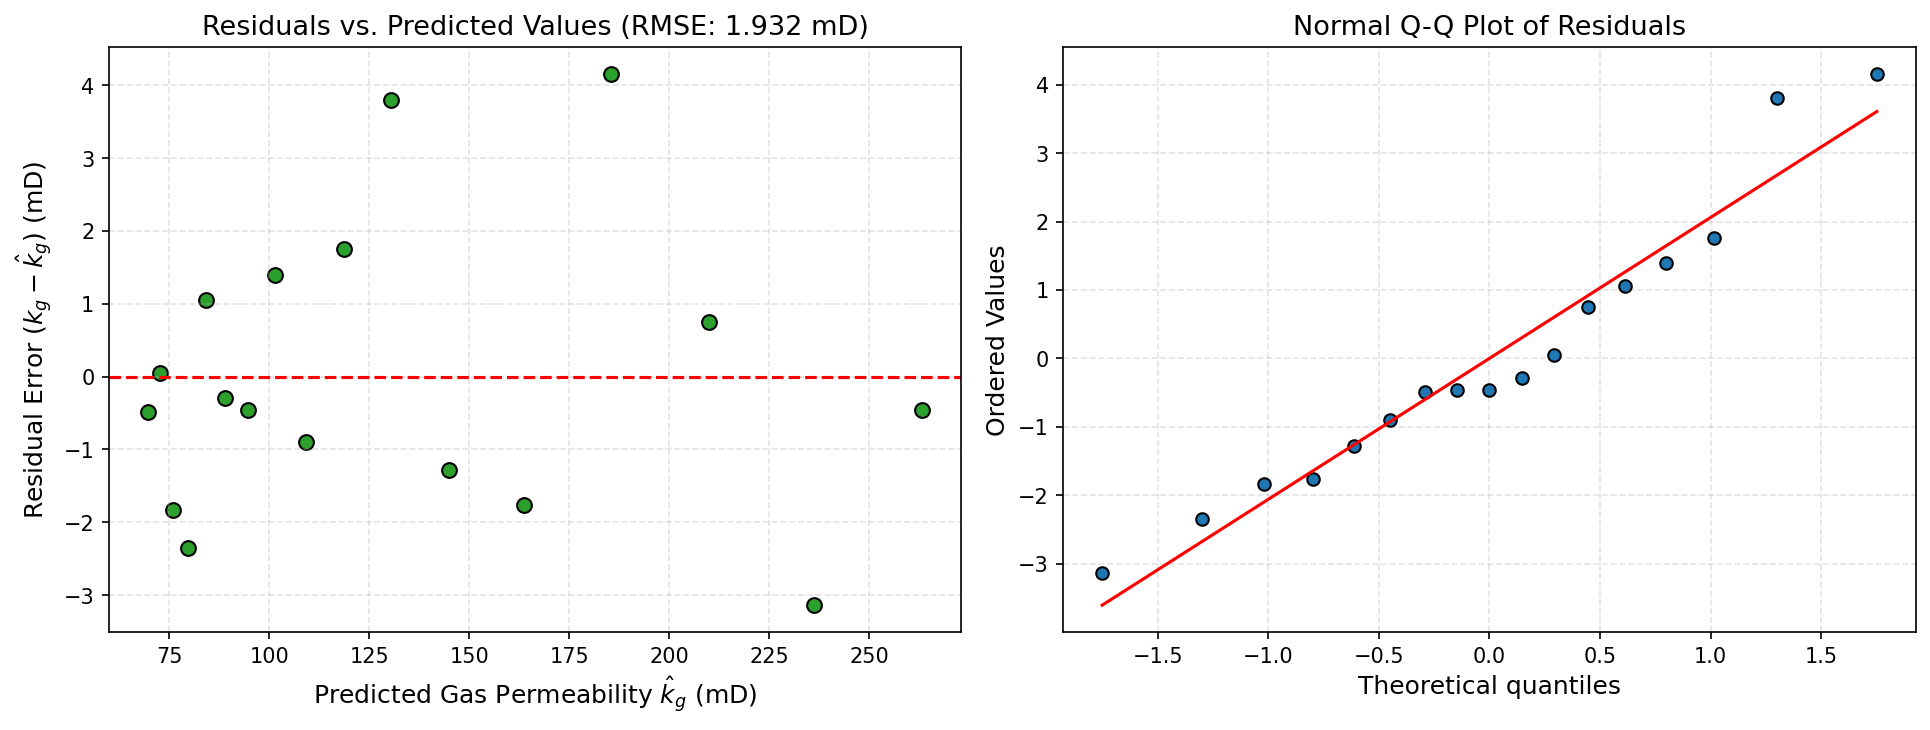

Error Metrics Summary:
  - Root Mean Squared Error (RMSE): 1.9321 mD
  - Mean Absolute Error (MAE): 1.5248 mD


In [7]:
# Calculate evaluation metrics
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Plot Figure 3 & 4: Residual Diagnostic Suite
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Residuals vs Fitted values
ax1.scatter(y_pred_data, residuals, color='#2ca02c', edgecolor='k', s=50)
ax1.axhline(0, color='red', linestyle='--', lw=1.5)
ax1.set_title(f'Residuals vs. Predicted Values (RMSE: {rmse:.3f} mD)')
ax1.set_xlabel(r'Predicted Gas Permeability $\hat{k}_g$ (mD)')
ax1.set_ylabel(r'Residual Error $(k_g - \hat{k}_g)$ (mD)')

# Subplot 2: Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('#1f77b4')
ax2.get_lines()[0].set_markeredgecolor('k')
ax2.get_lines()[1].set_color('red')
ax2.set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('Figure3_Residual_Diagnostics.png', dpi=300)
plt.show()

print(f"Error Metrics Summary:")
print(f"  - Root Mean Squared Error (RMSE): {rmse:.4f} mD")
print(f"  - Mean Absolute Error (MAE): {mae:.4f} mD")

## 13. Practical Engineering Implications & Recommendations

1. **Tight Gas & Unconventional Reservoirs:** Slippage effects are dramatic in low-permeability rocks ($k < 0.1\text{ mD}$). Uncorrected routine gas measurements can overestimate reservoir flow capacity by **$200\% - 500\%$** at atmospheric pore pressures.
2. **Core Testing Protocols (API RP 40):** Standard laboratory core analysis must perform multi-pressure flow runs to extrapolate $k_l$. Single-point gas tests yield erroneous results.
3. **Reservoir Simulation Input:** Dynamic flow simulators require absolute liquid permeability ($k_l$). Using raw gas permeability leads to unrealistically optimistic production forecasts.

## 14. Conclusions
- **Liquid Permeability ($k_l$):** Calculated via $1/P_m \to 0$ intercept.
- **Slippage Factor ($b$):** Calculated via linear slope ratio.
- **Fit Quality:** Validated with $R^2$, RMSE, and normal Q-Q residual plots.